# QRC summary tables and heatmaps

### Notebook Objective

Generates thesis-ready (`.tex` / `.png`) artifacts derived from
`results_comparative.csv`, **for the QRC model only**:

1. **Per-dataset LaTeX tables** in `../reports/tabele/` — four target
   configurations per dataset (best overall, best at lr=1.0, best at
   window_size=1, and the fixed lr=0.5/ws=6 point).
2. **Per-dataset heatmaps** in `../reports/heatmaps/` — `window_size`
   on the X-axis, `leakage_rate` on the Y-axis, color = test NMSE.
3. **One summary LaTeX table** with the single best QRC model per dataset.

NMSE is computed post-hoc from the existing CSV by dividing each MSE by the
variance of the corresponding target window (deterministic given the data
profile and `window_size`). No re-run is required.

The **test NMSE** (`median_test_nmse`) is used for both selection and
reporting in this notebook — these are descriptive tables of optimum
performance for the thesis.


In [1]:
# === IMPORTS AND SETUP ===
import sys
import os
import re

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Rectangle

from src.data_generation import (
    mackey_glass, generate_arma_data, generate_narma_data, create_io_pairs,
)
from src.experiment import sliding_cv_folds, WASHOUT

%load_ext autoreload
%autoreload 2

# --- Paths and constants ---
RESULTS_FILE   = '../data/results_comparative.csv'
TABELE_DIR     = '../reports/tabele'
HEATMAPS_DIR   = '../reports/heatmaps'
TRAIN_FRACTION = 0.8
N_SPLITS       = 5

os.makedirs(TABELE_DIR,   exist_ok=True)
os.makedirs(HEATMAPS_DIR, exist_ok=True)

# --- Load CSV and isolate QRC rows ---
if not os.path.exists(RESULTS_FILE):
    raise FileNotFoundError(
        f"{RESULTS_FILE} not found. Run 1_run_experiments.ipynb first."
    )

results_df = pd.read_csv(RESULTS_FILE)
qrc_df = results_df[results_df['model_type'] == 'QRC'].copy()

print(f"Loaded {len(results_df)} total rows ({len(qrc_df)} QRC rows).")
print(f"Profiles: {sorted(qrc_df['data_profile'].unique())}")
print(f"window_size values: {sorted(qrc_df['window_size'].unique())}")
print(f"leakage_rate values: {sorted(qrc_df['leakage_rate'].unique())}")


Loaded 432 total rows (216 QRC rows).
Profiles: ['ARMA_InputDriven', 'Mackey_Glass_(tau=100)', 'Mackey_Glass_(tau=17)', 'Mackey_Glass_(tau=30)', 'NARMA10_InputDriven', 'NARMA5_InputDriven']
window_size values: [np.int64(1), np.int64(2), np.int64(4), np.int64(6), np.int64(8), np.int64(10)]
leakage_rate values: [np.float64(0.1), np.float64(0.3), np.float64(0.5), np.float64(0.7), np.float64(0.9), np.float64(1.0)]


## Compute NMSE columns

`NMSE = MSE / Var(targets)`. The variance is deterministic given the
`(data_profile, window_size)` pair — we regenerate the time series, slice
the test segment (and the K pooled CV val segments), apply `create_io_pairs`,
discard the `WASHOUT` initial rows, and take `np.var` of the remainder.

Computed once and cached: 6 profiles × 6 window sizes = 36 variance values per
metric (test, CV).


In [2]:
# Map data_profile string -> generator callable.
# Includes BOTH legacy autoregressive names AND new input-driven names so this
# notebook works against either CSV vintage. Only profile_names actually present
# in qrc_df are processed; the rest are silently skipped.
from src.data_generation import (
    generate_arma_input_driven_data,
    generate_narma_input_driven_data,
    make_io_pairs, series_length, slice_series,
)

PROFILE_GENERATORS = {
    # Mackey-Glass (unchanged across pipeline versions)
    'Mackey_Glass_(tau=17)':  lambda: mackey_glass(tau=17),
    'Mackey_Glass_(tau=30)':  lambda: mackey_glass(tau=30),
    'Mackey_Glass_(tau=100)': lambda: mackey_glass(tau=100),
    # Legacy autoregressive names (older CSV)
    'ARMA_1_2_stochastic':    lambda: generate_arma_data(),
    'NARMA10_Chaotic':        lambda: generate_narma_data(order=10),
    'NARMA5_Chaotic':         lambda: generate_narma_data(order=5),
    # New input-driven names (newer CSV)
    'ARMA_InputDriven':       lambda: generate_arma_input_driven_data(),
    'NARMA10_InputDriven':    lambda: generate_narma_input_driven_data(order=10),
    'NARMA5_InputDriven':     lambda: generate_narma_input_driven_data(order=5),
}


def split_cv_pool_test(ts, train_fraction):
    """Handles both 1D arrays and (s, y) tuples."""
    n = series_length(ts)
    cv_end = int(n * train_fraction)
    return slice_series(ts, 0, cv_end), slice_series(ts, cv_end, n)


# Build variance cache: (profile, window_size) -> {'test': Var, 'cv': Var}
var_cache = {}
unique_window_sizes = sorted(qrc_df['window_size'].astype(int).unique())

for profile_name, gen_fn in PROFILE_GENERATORS.items():
    if profile_name not in qrc_df['data_profile'].unique():
        continue
    ts = gen_fn()
    cv_pool, test_data = split_cv_pool_test(ts, TRAIN_FRACTION)
    folds = sliding_cv_folds(cv_pool, N_SPLITS)

    for ws in unique_window_sizes:
        # Test target variance — dispatch handles autoregressive vs input-driven
        _, y_test = make_io_pairs(test_data, ws)
        var_test = float(np.var(y_test[WASHOUT:]))

        # Pooled CV target variance (concatenated across folds)
        y_cv_pool = np.concatenate([
            make_io_pairs(val, ws)[1][WASHOUT:] for _, val in folds
        ])
        var_cv = float(np.var(y_cv_pool))

        var_cache[(profile_name, ws)] = {'test': var_test, 'cv': var_cv}

# Diagnostic: confirm coverage
covered = sorted({p for (p, _) in var_cache.keys()})
print(f"var_cache built for {len(covered)} profiles: {covered}")
missing = sorted(set(qrc_df['data_profile'].unique()) - set(covered))
if missing:
    print(f"WARNING: profiles in CSV but not in PROFILE_GENERATORS: {missing}")

# Attach as columns
def _lookup(row, key):
    entry = var_cache.get((row['data_profile'], int(row['window_size'])))
    return entry[key] if entry else np.nan

qrc_df['test_var'] = qrc_df.apply(lambda r: _lookup(r, 'test'), axis=1)
qrc_df['cv_var']   = qrc_df.apply(lambda r: _lookup(r, 'cv'),   axis=1)
qrc_df['median_test_nmse'] = qrc_df['median_test_mse'] / qrc_df['test_var']
qrc_df['median_cv_nmse']   = qrc_df['median_cv_mse']   / qrc_df['cv_var']

print("\nNMSE summary (per profile, min/max test NMSE):")
print(qrc_df.groupby('data_profile')['median_test_nmse']
      .agg(['min', 'max', 'count']).round(6))

var_cache built for 6 profiles: ['ARMA_InputDriven', 'Mackey_Glass_(tau=100)', 'Mackey_Glass_(tau=17)', 'Mackey_Glass_(tau=30)', 'NARMA10_InputDriven', 'NARMA5_InputDriven']

NMSE summary (per profile, min/max test NMSE):
                             min       max  count
data_profile                                     
ARMA_InputDriven        0.000075  0.682356     36
Mackey_Glass_(tau=100)  0.000220  0.524540     36
Mackey_Glass_(tau=17)   0.000040  0.649990     36
Mackey_Glass_(tau=30)   0.000040  0.450945     36
NARMA10_InputDriven     0.306108  0.731665     36
NARMA5_InputDriven      0.117681  0.681740     36


In [3]:
# === FORMATTING HELPERS ===

def fmt_sci(x, sig=2):
    """Scientific-notation LaTeX math: $1.23 \\times 10^{-3}$."""
    if pd.isna(x):
        return r'\textemdash'
    if x == 0:
        return '$0$'
    exp  = int(np.floor(np.log10(abs(x))))
    mant = x / 10**exp
    return rf'${mant:.{sig}f} \times 10^{{{exp}}}$'


def safe_filename(name: str) -> str:
    """File-system-safe identifier built from a profile name."""
    return re.sub(r'[^\w]+', '_', name).strip('_')


def latex_escape(s: str) -> str:
    """Escape characters that have special meaning in LaTeX text mode."""
    return (
        s.replace('\\', r'\textbackslash{}')
         .replace('&', r'\&')
         .replace('%', r'\%')
         .replace('#', r'\#')
         .replace('_', r'\_')
    )

print("Helper functions ready.")


Helper functions ready.


## 1. Per-dataset LaTeX tables

For each data profile, generate a 4-row table with the following configurations:

1. **Najlepszy wg NMSE** — overall lowest test NMSE in the QRC grid.
2. **Najlepszy przy lr=1.0** — best test NMSE constrained to `leakage_rate = 1.0`
   (pure sliding-window memory ablation).
3. **Najlepszy przy ws=1** — best test NMSE constrained to `window_size = 1`
   (pure leaky-integrator memory ablation, no quantum entanglement).
4. **Konfiguracja lr=0.5, ws=6** — fixed mid-point reference.

Each table is saved as a separate `.tex` file. Drop them into Overleaf with
`\input{...}` (requires `booktabs` package: `\usepackage{booktabs}`).


In [4]:
def generate_dataset_table(profile_df, profile_name):
    """Build a 4-row LaTeX table for one data profile. Returns the .tex source."""
    configs = []

    # 1. Overall best by test NMSE
    best_overall = profile_df.loc[profile_df['median_test_nmse'].idxmin()]
    configs.append(('Najlepszy wg NMSE', best_overall))

    # 2. Best at lr = 1.0
    lr1 = profile_df[np.isclose(profile_df['leakage_rate'], 1.0)]
    if not lr1.empty:
        configs.append(('Najlepszy przy lr=1.0',
                        lr1.loc[lr1['median_test_nmse'].idxmin()]))

    # 3. Best at window_size = 1
    ws1 = profile_df[profile_df['window_size'].astype(int) == 1]
    if not ws1.empty:
        configs.append(('Najlepszy przy ws=1',
                        ws1.loc[ws1['median_test_nmse'].idxmin()]))

    # 4. Fixed (lr=0.5, ws=6) — slim grid has exactly one row
    spec = profile_df[
        np.isclose(profile_df['leakage_rate'], 0.5) &
        (profile_df['window_size'].astype(int) == 6)
    ]
    if not spec.empty:
        configs.append(('Konfiguracja lr=0.5, ws=6', spec.iloc[0]))

    label = safe_filename(profile_name).lower()
    pname_tex = latex_escape(profile_name)

    lines = [
        r'\begin{table}[ht]',
        r'\centering',
        rf'\caption{{Najlepsze modele QRC dla zbioru \texttt{{{pname_tex}}}.}}',
        rf'\label{{tab:qrc-{label}}}',
        r'\begin{tabular}{lccc}',
        r'\toprule',
        r'Konfiguracja & NMSE & leakage rate & window size \\',
        r'\midrule',
    ]
    for cfg_name, row in configs:
        nmse_str = fmt_sci(row['median_test_nmse'])
        lr = row['leakage_rate']
        ws = int(row['window_size'])
        lines.append(rf'{cfg_name} & {nmse_str} & {lr} & {ws} \\')
    lines += [
        r'\bottomrule',
        r'\end{tabular}',
        r'\end{table}',
    ]
    return '\n'.join(lines)


# Generate one .tex per profile (in the order seen in the CSV)
seen_profiles = []
for pname in qrc_df['data_profile'].unique():
    sub = qrc_df[qrc_df['data_profile'] == pname]
    tex_source = generate_dataset_table(sub, pname)

    out_path = f'{TABELE_DIR}/qrc_table_{safe_filename(pname)}.tex'
    with open(out_path, 'w', encoding='utf-8') as f:
        f.write(tex_source)
    seen_profiles.append(pname)
    print(f'Wrote {out_path}')

# Preview the first one
print('\n--- Preview of first table ---\n')
with open(f'{TABELE_DIR}/qrc_table_{safe_filename(seen_profiles[0])}.tex',
          encoding='utf-8') as f:
    print(f.read())


Wrote ../reports/tabele/qrc_table_Mackey_Glass__tau_17.tex
Wrote ../reports/tabele/qrc_table_Mackey_Glass__tau_30.tex
Wrote ../reports/tabele/qrc_table_Mackey_Glass__tau_100.tex
Wrote ../reports/tabele/qrc_table_ARMA_InputDriven.tex
Wrote ../reports/tabele/qrc_table_NARMA10_InputDriven.tex
Wrote ../reports/tabele/qrc_table_NARMA5_InputDriven.tex

--- Preview of first table ---

\begin{table}[ht]
\centering
\caption{Najlepsze modele QRC dla zbioru \texttt{Mackey\_Glass\_(tau=17)}.}
\label{tab:qrc-mackey_glass__tau_17}
\begin{tabular}{lccc}
\toprule
Konfiguracja & NMSE & leakage rate & window size \\
\midrule
Najlepszy wg NMSE & $4.00 \times 10^{-5}$ & 1.0 & 10 \\
Najlepszy przy lr=1.0 & $4.00 \times 10^{-5}$ & 1.0 & 10 \\
Najlepszy przy ws=1 & $2.61 \times 10^{-2}$ & 1.0 & 1 \\
Konfiguracja lr=0.5, ws=6 & $1.64 \times 10^{-4}$ & 0.5 & 6 \\
\bottomrule
\end{tabular}
\end{table}


## 2. Heatmaps of test NMSE per dataset

For each data profile, a 6×6 heatmap showing `median_test_nmse` across the
full QRC sub-grid (`window_size` on X, `leakage_rate` on Y, color on log scale).
The cell with the lowest NMSE is highlighted with a red border.

Saved as `qrc_heatmap_<profile>.png` in `../reports/heatmaps/`.


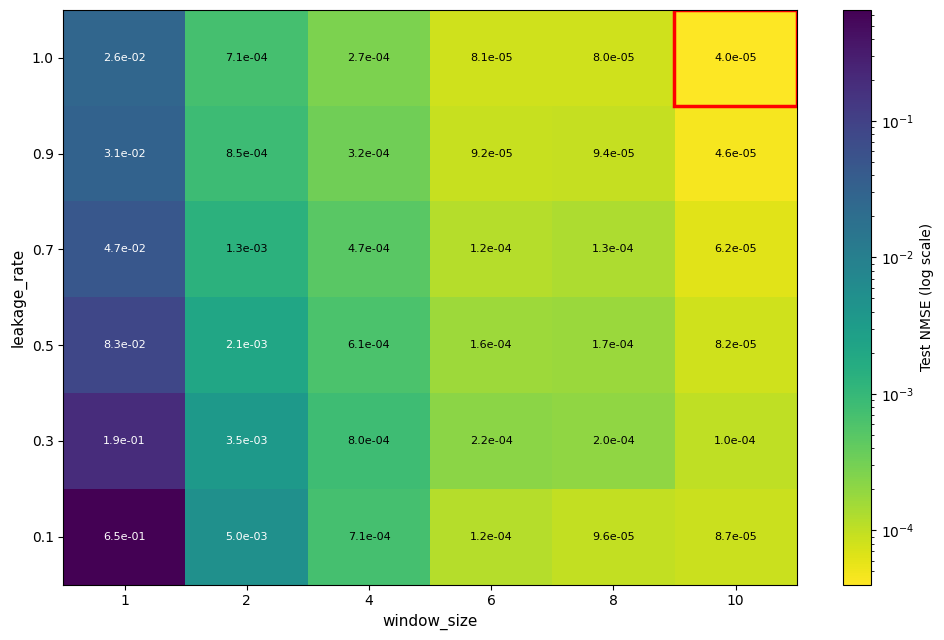

Wrote ../reports/heatmaps/qrc_heatmap_Mackey_Glass__tau_17.png


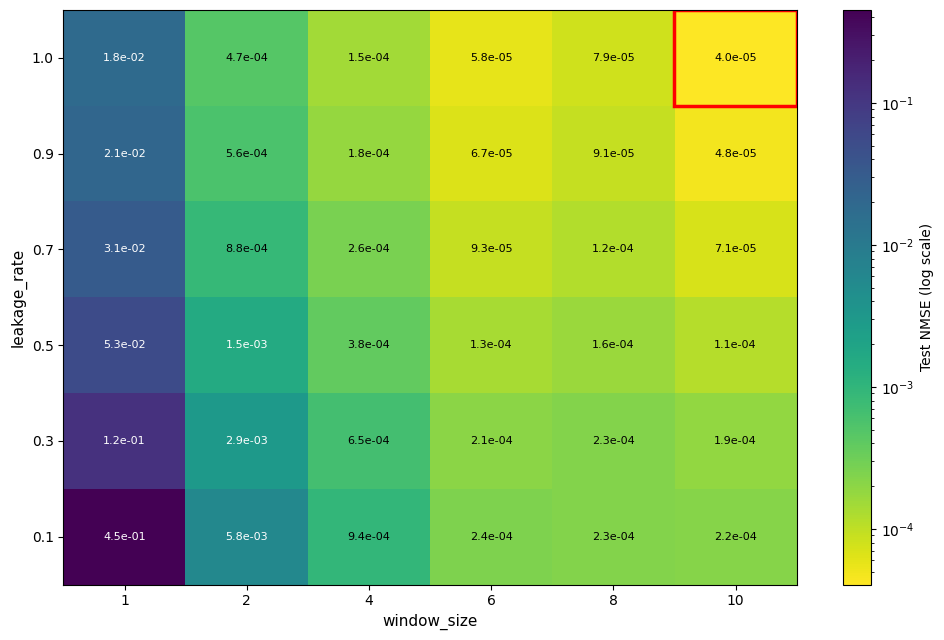

Wrote ../reports/heatmaps/qrc_heatmap_Mackey_Glass__tau_30.png


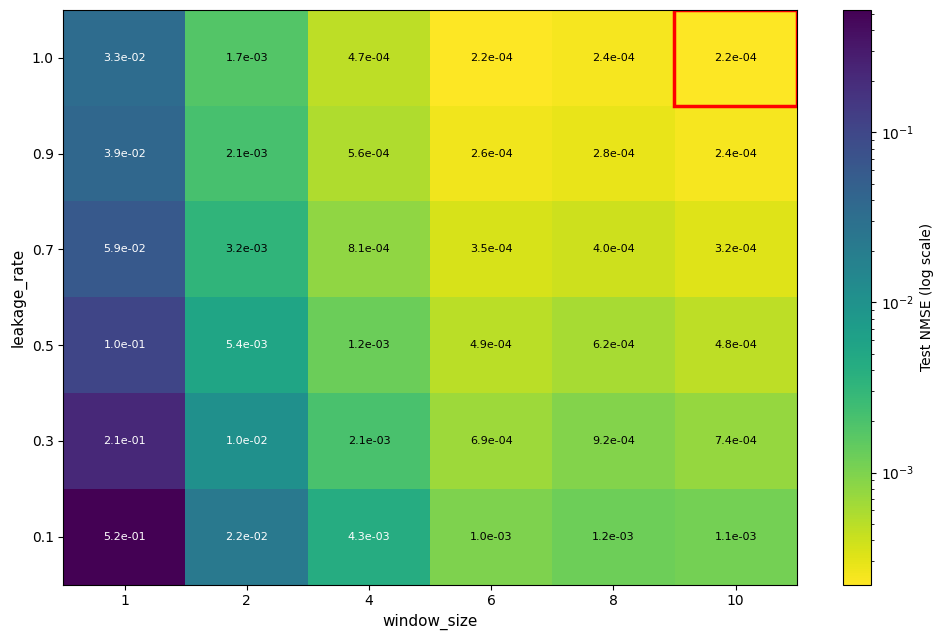

Wrote ../reports/heatmaps/qrc_heatmap_Mackey_Glass__tau_100.png


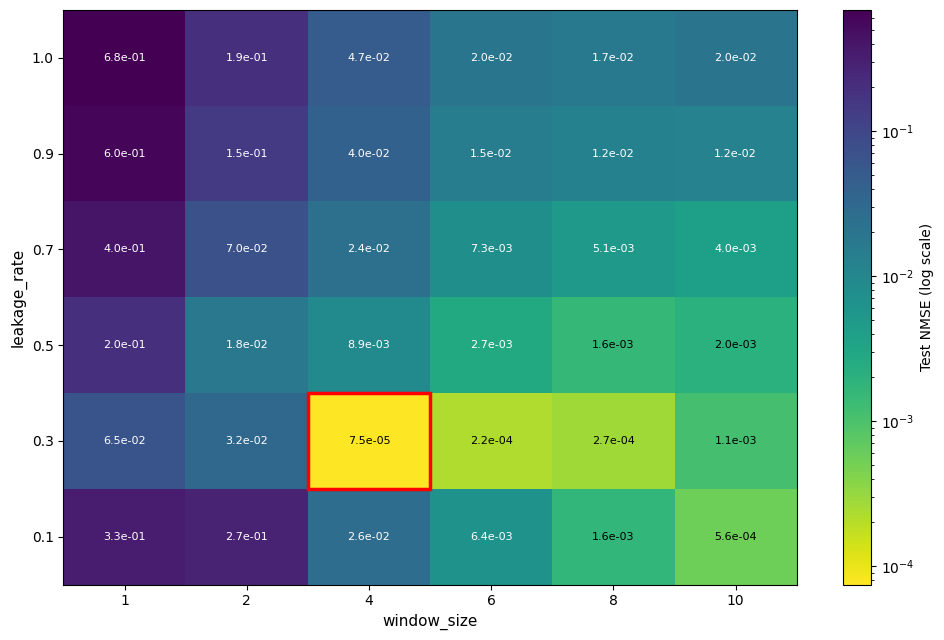

Wrote ../reports/heatmaps/qrc_heatmap_ARMA_InputDriven.png


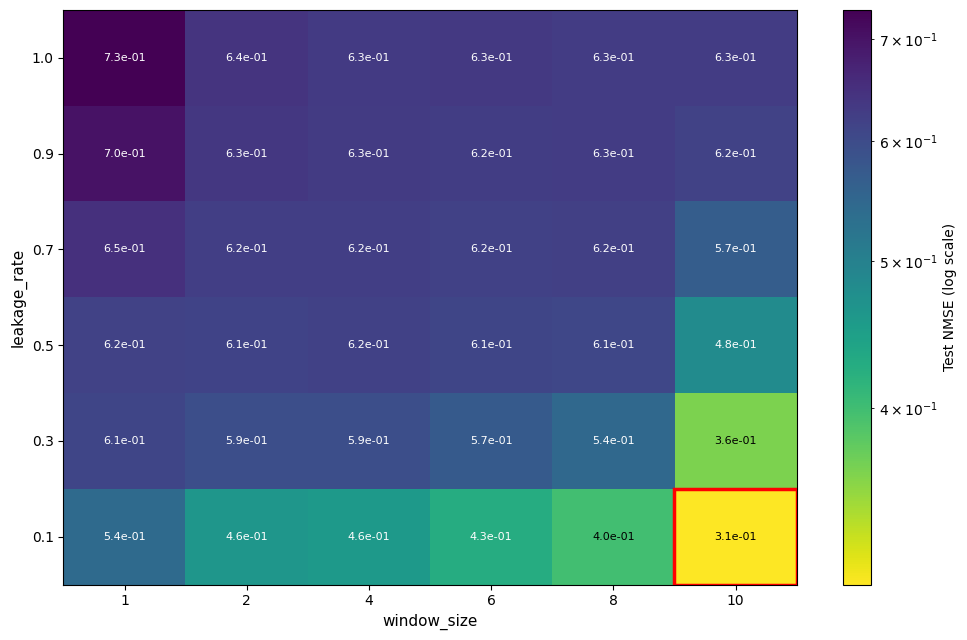

Wrote ../reports/heatmaps/qrc_heatmap_NARMA10_InputDriven.png


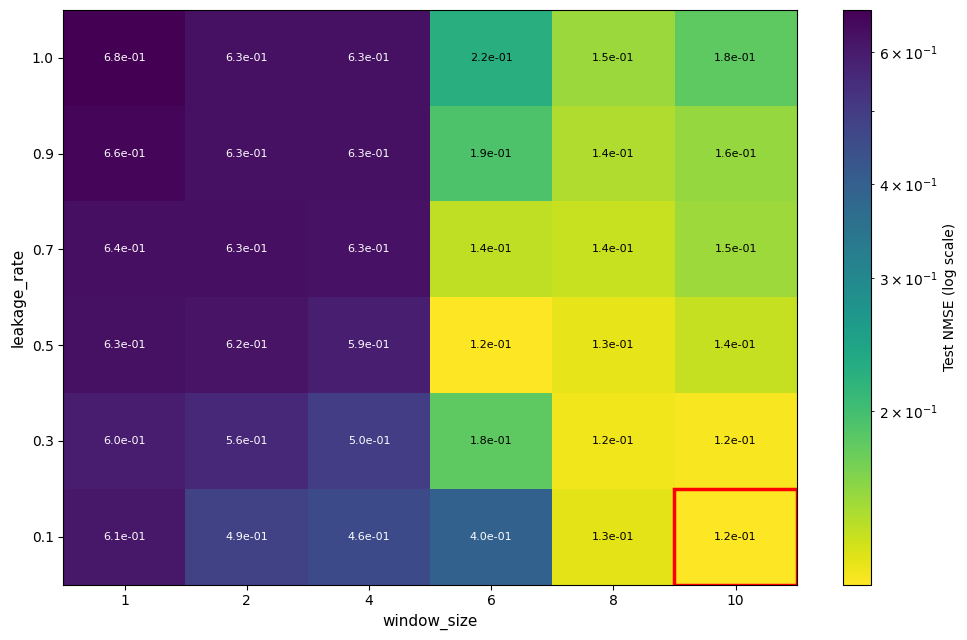

Wrote ../reports/heatmaps/qrc_heatmap_NARMA5_InputDriven.png


In [5]:
def generate_heatmap(profile_df, profile_name):
    """6×6 heatmap with red border on the optimum cell. Returns saved path."""
    pivot = profile_df.pivot_table(
        index='leakage_rate', columns='window_size',
        values='median_test_nmse', aggfunc='first',
    )
    # Higher leakage rates at the TOP (visual convention).
    pivot = pivot.sort_index(ascending=False)
    pivot = pivot.reindex(columns=sorted(pivot.columns))

    fig, ax = plt.subplots(figsize=(10, 6.5))
    vals = pivot.values.astype(float)
    vmin = float(np.nanmin(vals[vals > 0])) if np.any(vals > 0) else 1e-12
    vmax = float(np.nanmax(vals))

    im = ax.imshow(vals, aspect='auto', cmap='viridis_r',
                   norm=LogNorm(vmin=vmin, vmax=vmax))

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([int(c) for c in pivot.columns])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f'{lr:.1f}' for lr in pivot.index])
    ax.set_xlabel('window_size', fontsize=11)
    ax.set_ylabel('leakage_rate', fontsize=11)

    # Annotate cells; choose text color by background luminance
    cmap = plt.cm.viridis_r
    norm = LogNorm(vmin=vmin, vmax=vmax)
    for i in range(vals.shape[0]):
        for j in range(vals.shape[1]):
            v = vals[i, j]
            if np.isnan(v) or v <= 0:
                continue
            rgba = cmap(norm(v))
            lum = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
            text_color = 'white' if lum < 0.5 else 'black'
            ax.text(j, i, f'{v:.1e}',
                    ha='center', va='center', fontsize=8, color=text_color)

    # Highlight optimum
    flat_idx = np.nanargmin(vals)
    min_idx = np.unravel_index(flat_idx, vals.shape)
    ax.add_patch(Rectangle(
        (min_idx[1] - 0.5, min_idx[0] - 0.5), 1, 1,
        fill=False, edgecolor='red', linewidth=2.5,
    ))

    fig.colorbar(im, ax=ax, label='Test NMSE (log scale)')
    fig.tight_layout()
    out_path = f'{HEATMAPS_DIR}/qrc_heatmap_{safe_filename(profile_name)}.png'
    fig.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()
    return out_path


for pname in seen_profiles:
    sub = qrc_df[qrc_df['data_profile'] == pname]
    out = generate_heatmap(sub, pname)
    print(f'Wrote {out}')


## 3. Summary LaTeX table — best QRC model per dataset

Single table aggregating the **overall best QRC configuration** (lowest test
NMSE) for each data profile, with its NMSE, leakage rate and window size.

Saved as `qrc_summary_all_datasets.tex` in `../reports/tabele/`.


In [6]:
summary_rows = []
for pname in seen_profiles:
    sub = qrc_df[qrc_df['data_profile'] == pname]
    best = sub.loc[sub['median_test_nmse'].idxmin()]
    summary_rows.append({
        'profile': pname,
        'nmse': best['median_test_nmse'],
        'lr': best['leakage_rate'],
        'ws': int(best['window_size']),
    })

# Build LaTeX
lines = [
    r'\begin{table}[ht]',
    r'\centering',
    r'\caption{Najlepsze modele QRC dla wszystkich badanych zbiorów danych.}',
    r'\label{tab:qrc-summary-all}',
    r'\begin{tabular}{lccc}',
    r'\toprule',
    r'Zbiór danych & NMSE & leakage rate & window size \\',
    r'\midrule',
]
for r in summary_rows:
    pname_tex = latex_escape(r['profile'])
    nmse_str  = fmt_sci(r['nmse'])
    lines.append(rf'\texttt{{{pname_tex}}} & {nmse_str} & {r["lr"]} & {r["ws"]} \\')
lines += [
    r'\bottomrule',
    r'\end{tabular}',
    r'\end{table}',
]
summary_tex = '\n'.join(lines)

summary_path = f'{TABELE_DIR}/qrc_summary_all_datasets.tex'
with open(summary_path, 'w', encoding='utf-8') as f:
    f.write(summary_tex)
print(f'Wrote {summary_path}\n')

# Preview
print('--- LaTeX content ---\n')
print(summary_tex)


Wrote ../reports/tabele/qrc_summary_all_datasets.tex

--- LaTeX content ---

\begin{table}[ht]
\centering
\caption{Najlepsze modele QRC dla wszystkich badanych zbiorów danych.}
\label{tab:qrc-summary-all}
\begin{tabular}{lccc}
\toprule
Zbiór danych & NMSE & leakage rate & window size \\
\midrule
\texttt{Mackey\_Glass\_(tau=17)} & $4.00 \times 10^{-5}$ & 1.0 & 10 \\
\texttt{Mackey\_Glass\_(tau=30)} & $4.05 \times 10^{-5}$ & 1.0 & 10 \\
\texttt{Mackey\_Glass\_(tau=100)} & $2.20 \times 10^{-4}$ & 1.0 & 10 \\
\texttt{ARMA\_InputDriven} & $7.46 \times 10^{-5}$ & 0.3 & 4 \\
\texttt{NARMA10\_InputDriven} & $3.06 \times 10^{-1}$ & 0.1 & 10 \\
\texttt{NARMA5\_InputDriven} & $1.18 \times 10^{-1}$ & 0.1 & 10 \\
\bottomrule
\end{tabular}
\end{table}


## 4. QRC vs Classical ESN — direct comparison per dataset

Pojedyncza tabela z bezpośrednim porównaniem dwóch modeli per zbiór danych.
Każdy zbiór danych ma dwa wiersze (jeden dla QRC, jeden dla Classical ESN);
grupowanie pionowe zrealizowane przez `\multirow`.

Selekcja "najlepszego" modelu: najniższe **test NMSE** w obrębie modelu i zbioru.

Zapis do `../reports/tabele/qrc_vs_esn_comparison.tex`.

**Wymaga w preambule Overleafu:** `\usepackage{booktabs}` oraz `\usepackage{multirow}`.

In [7]:
# === BUILD QRC vs CLASSICAL ESN COMPARISON TABLE ===
# Build a long-form comparison table: per dataset, one row for the best QRC model
# and one row for the best Classical ESN model, grouped vertically via \multirow.

# Extract Classical rows from the original results_df and attach test NMSE.
# The variance cache built earlier is keyed by (profile, window_size) and covers
# the full window_size grid shared between QRC and Classical.
classical_df = results_df[results_df['model_type'] == 'Classical_ESN'].copy()


def _lookup_test_var(row):
    entry = var_cache.get((row['data_profile'], int(row['window_size'])))
    return entry['test'] if entry else np.nan


classical_df['test_var'] = classical_df.apply(_lookup_test_var, axis=1)
classical_df['median_test_nmse'] = classical_df['median_test_mse'] / classical_df['test_var']

# --- Build the LaTeX table ---
comp_lines = [
    r'\begin{table}[ht]',
    r'\centering',
    r'\caption{Bezpośrednie porównanie najlepszych modeli QRC i klasycznego ESN dla każdego zbioru danych. Selekcja w obrębie modelu i zbioru przez najniższe test NMSE.}',
    r'\label{tab:qrc-vs-esn-comparison}',
    r'\begin{tabular}{llccc}',
    r'\toprule',
    r'Zbiór danych & Model & NMSE & leakage rate & window size \\',
    r'\midrule',
]

n_profiles = len(seen_profiles)
for i, pname in enumerate(seen_profiles):
    pname_tex = latex_escape(pname)

    qrc_sub = qrc_df[qrc_df['data_profile'] == pname]
    cls_sub = classical_df[classical_df['data_profile'] == pname]

    if qrc_sub.empty or cls_sub.empty:
        print(f'--> Skipping {pname}: missing QRC or Classical rows')
        continue

    best_qrc = qrc_sub.loc[qrc_sub['median_test_nmse'].idxmin()]
    best_cls = cls_sub.loc[cls_sub['median_test_nmse'].idxmin()]

    qrc_nmse_str = fmt_sci(best_qrc['median_test_nmse'])
    cls_nmse_str = fmt_sci(best_cls['median_test_nmse'])

    # Row 1: dataset name (multirow), QRC model
    comp_lines.append(
        rf'\multirow{{2}}{{*}}{{\texttt{{{pname_tex}}}}} '
        rf'& QRC & {qrc_nmse_str} & {best_qrc["leakage_rate"]} & {int(best_qrc["window_size"])} \\'
    )
    # Row 2: empty dataset cell (handled by multirow), Classical model
    comp_lines.append(
        rf'& Classical ESN & {cls_nmse_str} & {best_cls["leakage_rate"]} & {int(best_cls["window_size"])} \\'
    )

    # \midrule between dataset groups (but not after the last)
    if i < n_profiles - 1:
        comp_lines.append(r'\midrule')

comp_lines += [
    r'\bottomrule',
    r'\end{tabular}',
    r'\end{table}',
]

comp_tex = '\n'.join(comp_lines)

comp_path = f'{TABELE_DIR}/qrc_vs_esn_comparison.tex'
with open(comp_path, 'w', encoding='utf-8') as f:
    f.write(comp_tex)
print(f'Wrote {comp_path}\n')

print('--- LaTeX content ---\n')
print(comp_tex)


Wrote ../reports/tabele/qrc_vs_esn_comparison.tex

--- LaTeX content ---

\begin{table}[ht]
\centering
\caption{Bezpośrednie porównanie najlepszych modeli QRC i klasycznego ESN dla każdego zbioru danych. Selekcja w obrębie modelu i zbioru przez najniższe test NMSE.}
\label{tab:qrc-vs-esn-comparison}
\begin{tabular}{llccc}
\toprule
Zbiór danych & Model & NMSE & leakage rate & window size \\
\midrule
\multirow{2}{*}{\texttt{Mackey\_Glass\_(tau=17)}} & QRC & $4.00 \times 10^{-5}$ & 1.0 & 10 \\
& Classical ESN & $4.35 \times 10^{-7}$ & 1.0 & 10 \\
\midrule
\multirow{2}{*}{\texttt{Mackey\_Glass\_(tau=30)}} & QRC & $4.05 \times 10^{-5}$ & 1.0 & 10 \\
& Classical ESN & $1.37 \times 10^{-6}$ & 1.0 & 6 \\
\midrule
\multirow{2}{*}{\texttt{Mackey\_Glass\_(tau=100)}} & QRC & $2.20 \times 10^{-4}$ & 1.0 & 10 \\
& Classical ESN & $9.95 \times 10^{-6}$ & 0.9 & 6 \\
\midrule
\multirow{2}{*}{\texttt{ARMA\_InputDriven}} & QRC & $7.46 \times 10^{-5}$ & 0.3 & 4 \\
& Classical ESN & $2.29 \times 10^{-5}$ &

## 5. Classical ESN — heatmapy NMSE per zbiór

Analogiczne do heatmap QRC (sekcja 2), ale dla klasycznego ESN. Pozwala wizualnie
porównać krajobrazy NMSE obu modeli przy identycznej siatce hiperparametrów
(`window_size × leakage_rate`).

Zapis: `../reports/heatmaps/classical_heatmap_<profile>.png`.

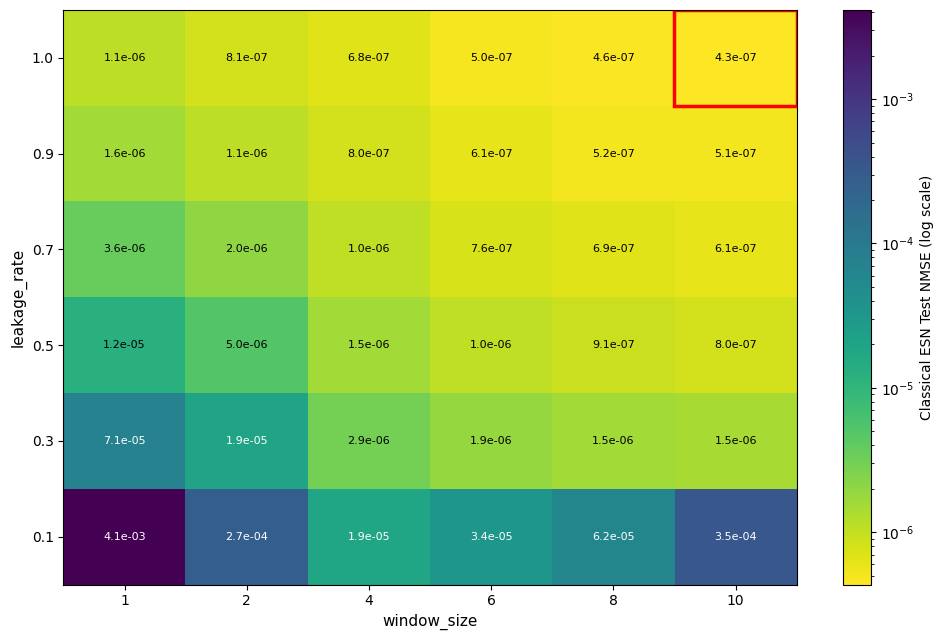

Wrote ../reports/heatmaps/classical_heatmap_Mackey_Glass__tau_17.png


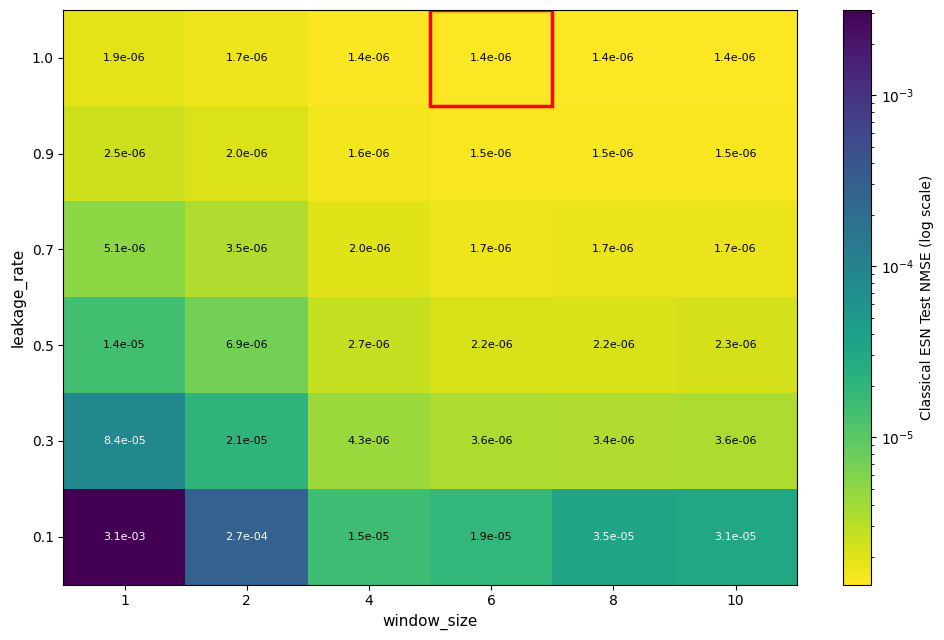

Wrote ../reports/heatmaps/classical_heatmap_Mackey_Glass__tau_30.png


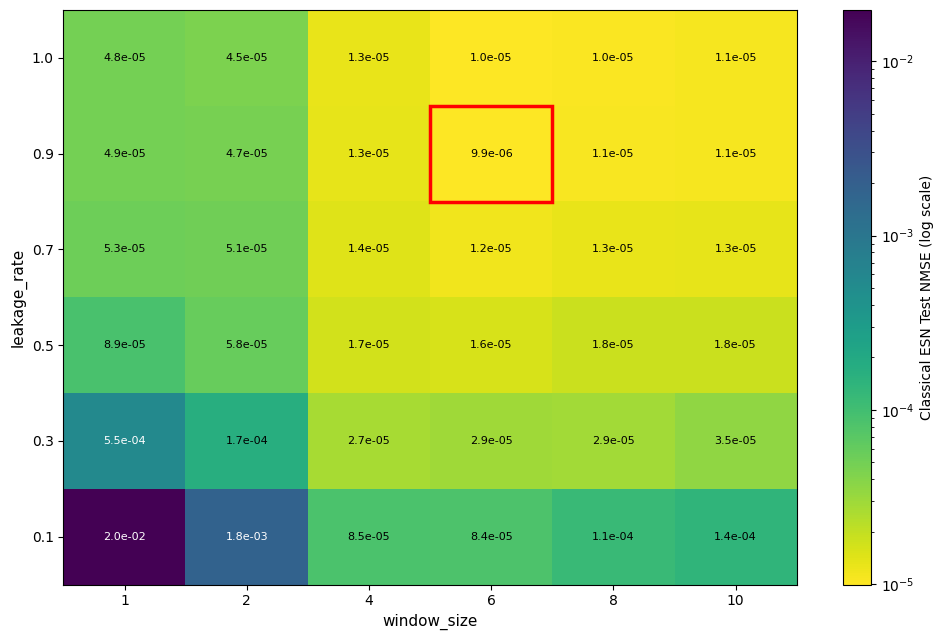

Wrote ../reports/heatmaps/classical_heatmap_Mackey_Glass__tau_100.png


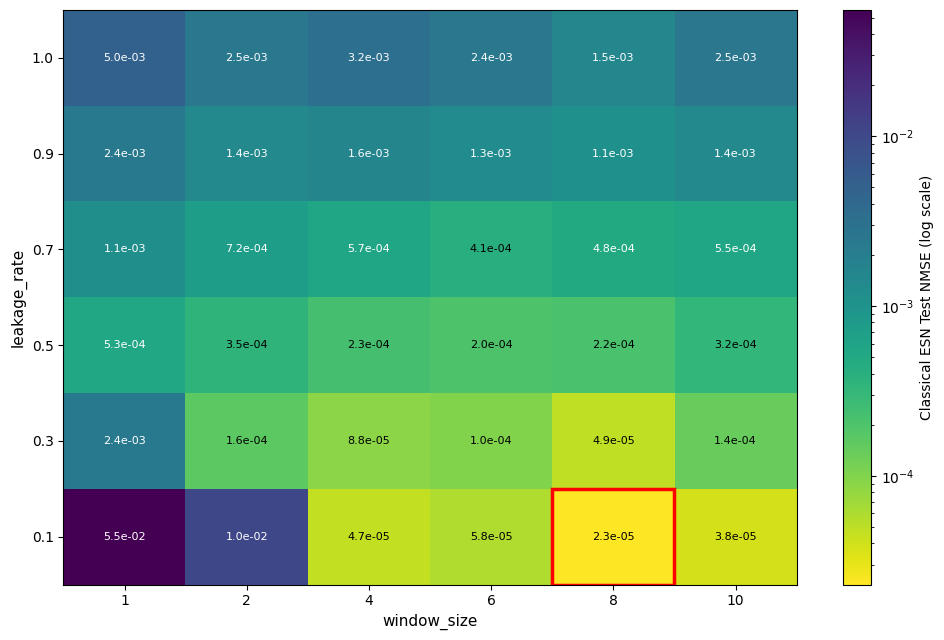

Wrote ../reports/heatmaps/classical_heatmap_ARMA_InputDriven.png


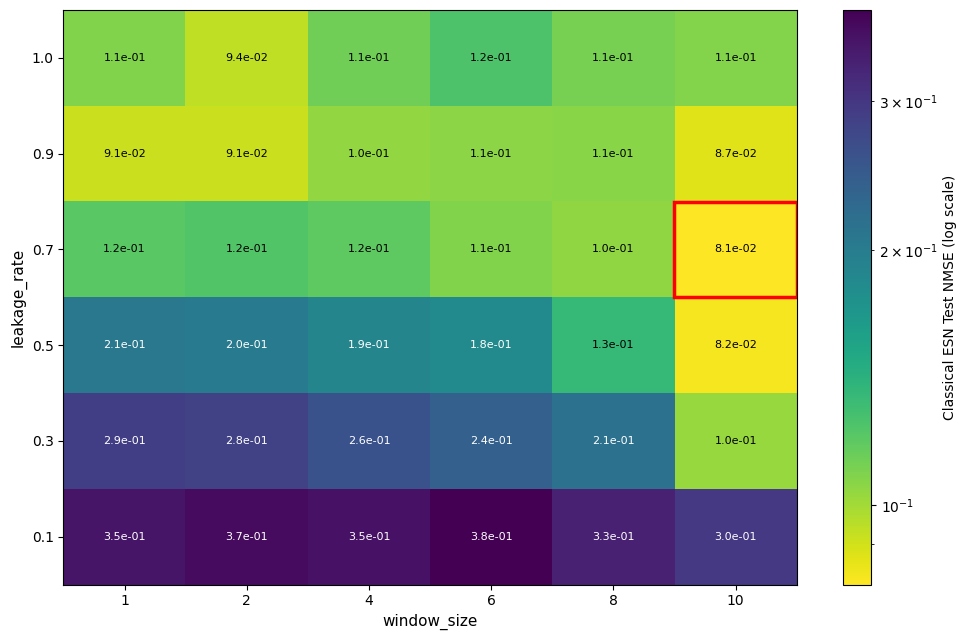

Wrote ../reports/heatmaps/classical_heatmap_NARMA10_InputDriven.png


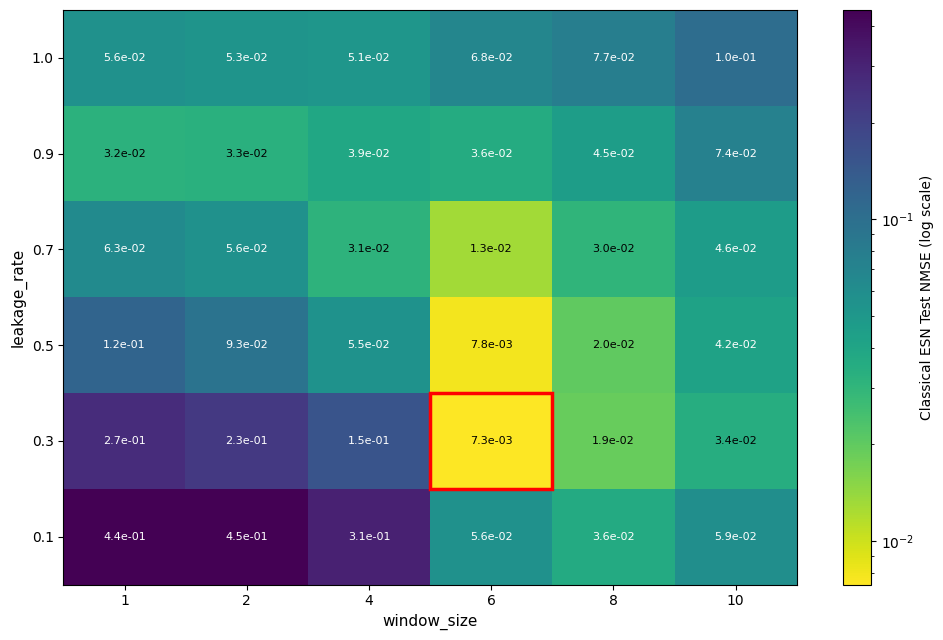

Wrote ../reports/heatmaps/classical_heatmap_NARMA5_InputDriven.png


In [8]:
# === CLASSICAL ESN NMSE HEATMAPS ===
# classical_df is defined in the comparison-table cell above (with median_test_nmse).
# We reuse the same plotting recipe as for QRC, but on the Classical rows.

def generate_classical_heatmap(profile_df, profile_name):
    """6×6 Classical ESN heatmap with red border on the optimum cell."""
    pivot = profile_df.pivot_table(
        index='leakage_rate', columns='window_size',
        values='median_test_nmse', aggfunc='first',
    )
    pivot = pivot.sort_index(ascending=False)
    pivot = pivot.reindex(columns=sorted(pivot.columns))

    fig, ax = plt.subplots(figsize=(10, 6.5))
    vals = pivot.values.astype(float)
    vmin = float(np.nanmin(vals[vals > 0])) if np.any(vals > 0) else 1e-12
    vmax = float(np.nanmax(vals))

    im = ax.imshow(vals, aspect='auto', cmap='viridis_r',
                   norm=LogNorm(vmin=vmin, vmax=vmax))

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([int(c) for c in pivot.columns])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f'{lr:.1f}' for lr in pivot.index])
    ax.set_xlabel('window_size', fontsize=11)
    ax.set_ylabel('leakage_rate', fontsize=11)

    cmap_obj = plt.cm.viridis_r
    norm_obj = LogNorm(vmin=vmin, vmax=vmax)
    for i in range(vals.shape[0]):
        for j in range(vals.shape[1]):
            v = vals[i, j]
            if np.isnan(v) or v <= 0:
                continue
            rgba = cmap_obj(norm_obj(v))
            lum = 0.299*rgba[0] + 0.587*rgba[1] + 0.114*rgba[2]
            text_color = 'white' if lum < 0.5 else 'black'
            ax.text(j, i, f'{v:.1e}',
                    ha='center', va='center', fontsize=8, color=text_color)

    flat_idx = np.nanargmin(vals)
    min_idx = np.unravel_index(flat_idx, vals.shape)
    ax.add_patch(Rectangle((min_idx[1] - 0.5, min_idx[0] - 0.5), 1, 1,
                           fill=False, edgecolor='red', linewidth=2.5))

    fig.colorbar(im, ax=ax, label='Classical ESN Test NMSE (log scale)')
    fig.tight_layout()
    out_path = f'{HEATMAPS_DIR}/classical_heatmap_{safe_filename(profile_name)}.png'
    fig.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()
    return out_path


for pname in seen_profiles:
    sub_cls = classical_df[classical_df['data_profile'] == pname]
    if sub_cls.empty:
        print(f'--> Skipping {pname}: no Classical rows')
        continue
    out = generate_classical_heatmap(sub_cls, pname)
    print(f'Wrote {out}')

## 6. Heatmapy różnicy QRC − Classical ESN per zbiór

Najmocniejsza pojedyncza wizualizacja dla Celu 3 pracy: kolorowa mapa różnicy
log-NMSE per komórka `(window_size, leakage_rate)`. Wartość komórki:

$$ \Delta = \log_{10}(\mathrm{NMSE}_\mathrm{QRC}) - \log_{10}(\mathrm{NMSE}_\mathrm{Classical}) $$

Interpretacja koloru:
- **niebieski** ($\Delta < 0$) → QRC ma **niższe** NMSE w tej komórce (QRC lepszy)
- **biały** ($\Delta \approx 0$) → remis
- **czerwony** ($\Delta > 0$) → Classical ma **niższe** NMSE (Classical lepszy)

Wartość liczbowa w celi to $\Delta$ — np. $-0.5$ znaczy że QRC ma NMSE 10× niższe
niż Classical, $+0.3$ znaczy że Classical ma NMSE 2× niższe niż QRC.

Pokazuje **w którym rogu** przestrzeni hiperparametrów każdy model wygrywa.

Zapis: `../reports/heatmaps/diff_heatmap_<profile>.png`.

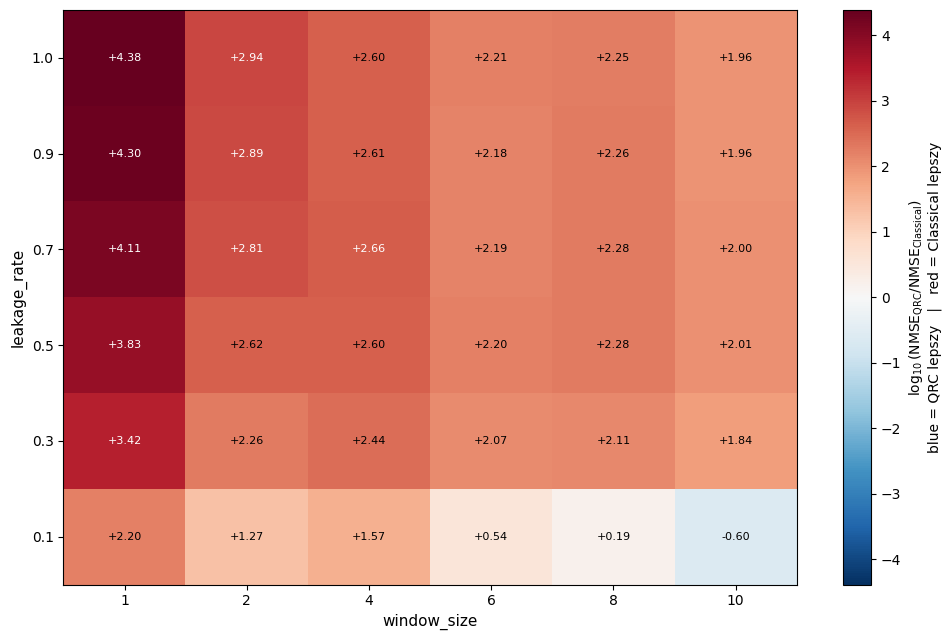

Wrote ../reports/heatmaps/diff_heatmap_Mackey_Glass__tau_17.png


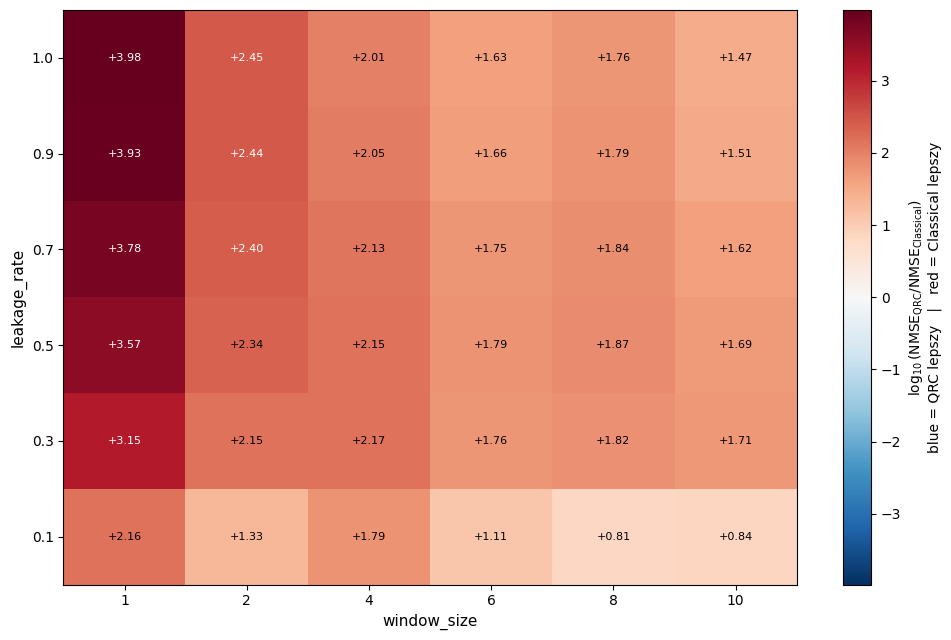

Wrote ../reports/heatmaps/diff_heatmap_Mackey_Glass__tau_30.png


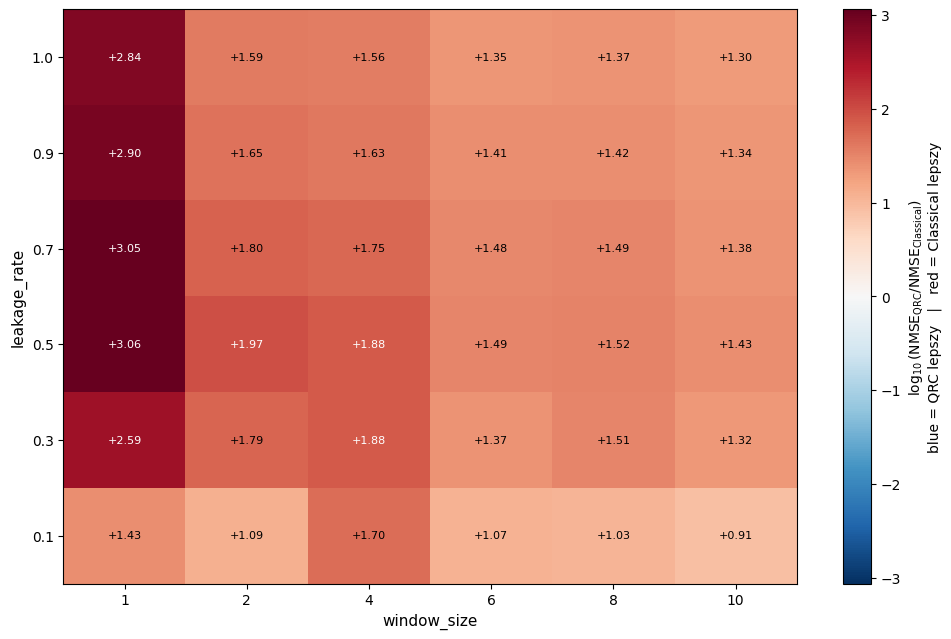

Wrote ../reports/heatmaps/diff_heatmap_Mackey_Glass__tau_100.png


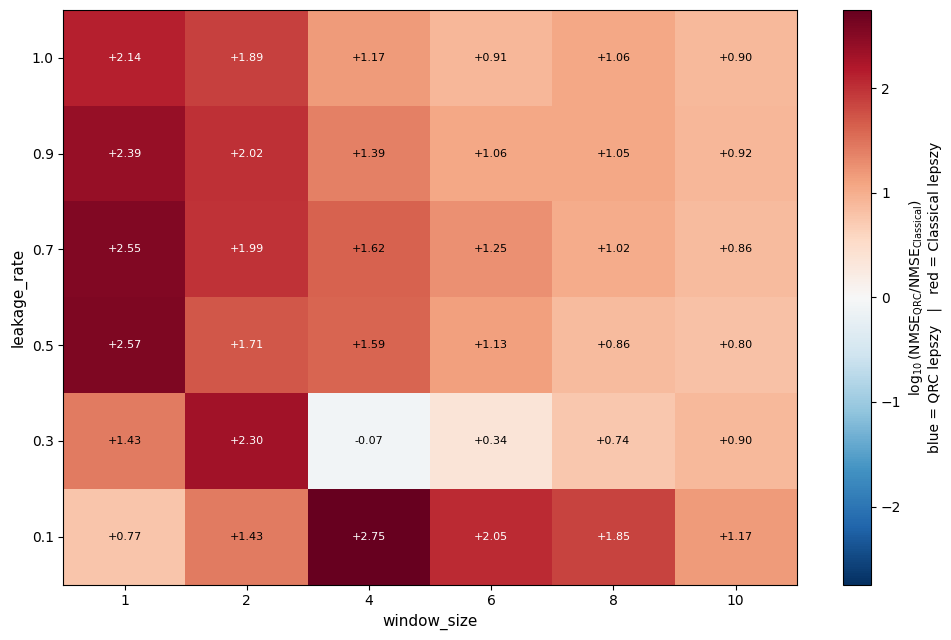

Wrote ../reports/heatmaps/diff_heatmap_ARMA_InputDriven.png


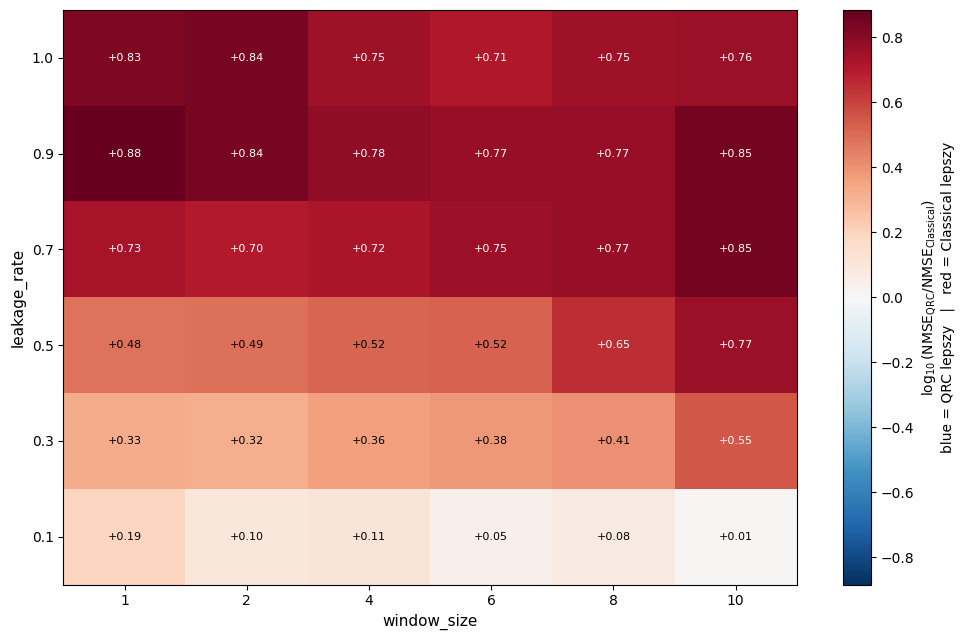

Wrote ../reports/heatmaps/diff_heatmap_NARMA10_InputDriven.png


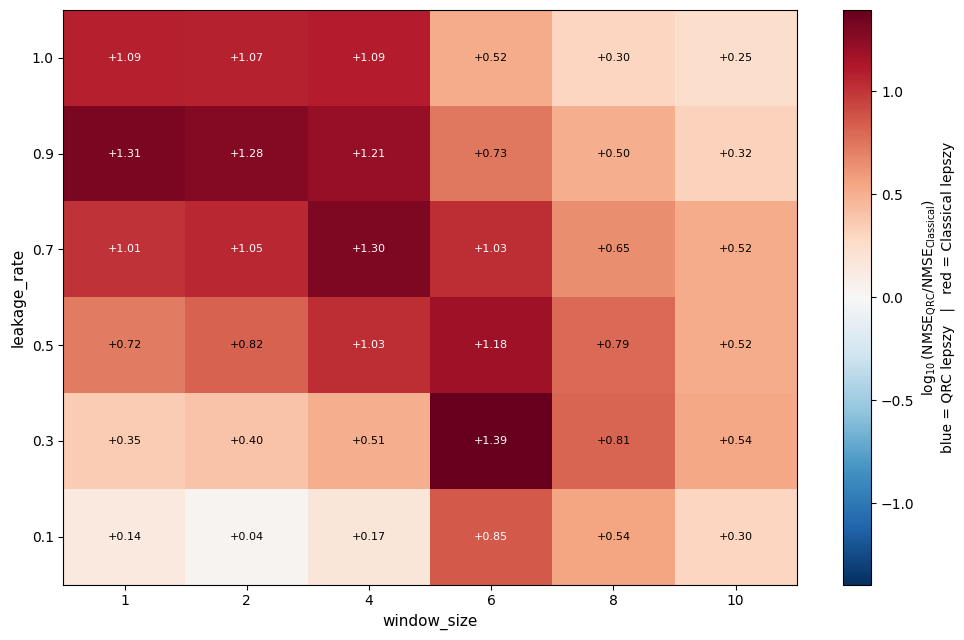

Wrote ../reports/heatmaps/diff_heatmap_NARMA5_InputDriven.png


In [9]:
# === QRC vs CLASSICAL ESN DIFFERENCE HEATMAPS ===
# Per cell (window_size, leakage_rate):
#     delta = log10(NMSE_QRC) - log10(NMSE_Classical)
# Blue = QRC wins; red = Classical wins; white = tie.

def generate_diff_heatmap(qrc_profile_df, cls_profile_df, profile_name):
    qrc_pivot = qrc_profile_df.pivot_table(
        index='leakage_rate', columns='window_size',
        values='median_test_nmse', aggfunc='first',
    ).sort_index(ascending=False)
    qrc_pivot = qrc_pivot.reindex(columns=sorted(qrc_pivot.columns))

    cls_pivot = cls_profile_df.pivot_table(
        index='leakage_rate', columns='window_size',
        values='median_test_nmse', aggfunc='first',
    ).sort_index(ascending=False)
    cls_pivot = cls_pivot.reindex(columns=sorted(cls_pivot.columns))

    # Align: keep only (lr, ws) cells present in both
    common_lrs = sorted(set(qrc_pivot.index) & set(cls_pivot.index), reverse=True)
    common_ws  = sorted(set(qrc_pivot.columns) & set(cls_pivot.columns))
    qrc_pivot = qrc_pivot.reindex(index=common_lrs, columns=common_ws)
    cls_pivot = cls_pivot.reindex(index=common_lrs, columns=common_ws)

    qrc_vals = qrc_pivot.values.astype(float)
    cls_vals = cls_pivot.values.astype(float)

    with np.errstate(divide='ignore', invalid='ignore'):
        diff = np.log10(qrc_vals) - np.log10(cls_vals)

    finite = diff[np.isfinite(diff)]
    if len(finite) == 0:
        print(f'--> Skipping {profile_name}: no finite diff values')
        return None
    vmax = float(np.max(np.abs(finite)))
    if vmax == 0:
        vmax = 1.0

    fig, ax = plt.subplots(figsize=(10, 6.5))
    im = ax.imshow(diff, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)

    ax.set_xticks(range(len(common_ws)))
    ax.set_xticklabels([int(c) for c in common_ws])
    ax.set_yticks(range(len(common_lrs)))
    ax.set_yticklabels([f'{lr:.1f}' for lr in common_lrs])
    ax.set_xlabel('window_size', fontsize=11)
    ax.set_ylabel('leakage_rate', fontsize=11)

    cmap_obj = plt.cm.RdBu_r
    norm_obj = plt.Normalize(vmin=-vmax, vmax=vmax)
    for i in range(diff.shape[0]):
        for j in range(diff.shape[1]):
            d = diff[i, j]
            if not np.isfinite(d):
                continue
            rgba = cmap_obj(norm_obj(d))
            lum = 0.299*rgba[0] + 0.587*rgba[1] + 0.114*rgba[2]
            text_color = 'white' if lum < 0.5 else 'black'
            ax.text(j, i, f'{d:+.2f}',
                    ha='center', va='center', fontsize=8, color=text_color)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(
        r'$\log_{10}(\mathrm{NMSE}_\mathrm{QRC} / \mathrm{NMSE}_\mathrm{Classical})$' + '\n'
        + 'blue = QRC lepszy   |   red = Classical lepszy',
        fontsize=10,
    )
    fig.tight_layout()
    out_path = f'{HEATMAPS_DIR}/diff_heatmap_{safe_filename(profile_name)}.png'
    fig.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()
    return out_path


for pname in seen_profiles:
    sub_qrc = qrc_df[qrc_df['data_profile'] == pname]
    sub_cls = classical_df[classical_df['data_profile'] == pname]
    if sub_qrc.empty or sub_cls.empty:
        print(f'--> Skipping {pname}: missing rows for one model')
        continue
    out = generate_diff_heatmap(sub_qrc, sub_cls, pname)
    if out:
        print(f'Wrote {out}')

---

### Output summary

**Tabele LaTeX** (`../reports/tabele/`):
- `qrc_table_<profile>.tex` — six per-dataset tables (4 configurations each)
- `qrc_summary_all_datasets.tex` — QRC overall winners
- `qrc_vs_esn_comparison.tex` — QRC vs Classical ESN side-by-side (requires `\usepackage{multirow}`)

**Heatmapy** (`../reports/heatmaps/`):
- `qrc_heatmap_<profile>.png` — six QRC NMSE landscape maps
- `classical_heatmap_<profile>.png` — six Classical ESN NMSE landscape maps
- `diff_heatmap_<profile>.png` — six QRC − Classical difference maps (log-NMSE,
  blue = QRC lepszy, red = Classical lepszy)

Each `.tex` file is a complete `table` environment ready to drop into Overleaf
with `\input{}`. Requires `\usepackage{booktabs}` (and `\usepackage{multirow}`
for the comparison table).

All artifacts are derived deterministically from `results_comparative.csv` plus
the data generators — re-running this notebook is idempotent and fast
(~tens of seconds).
